# Anomalous diffusion and coarse-graining
These notebooks accompany the first part of the course.

Main topics:
1. 1D continuous-time random walks (CTRWs).
2. Markovian benchmark dynamics.
3. Power-law waiting times and anomalous diffusion.
4. Ensemble-averaged and time-averaged MSD.
5. Weak ergodicity breaking.
6. Decimation and lumping as coarse-graining procedures.
7. Homework: iterative RG for decimation.

Throughout, we use simple NumPy/Matplotlib code so that the core ideas remain visible.


In this notebook, some sections are already completed, while others contain prompts and `TODO` blocks for you to fill in.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["figure.figsize"] = (14, 7)
plt.rcParams["axes.grid"] = True
rng = np.random.default_rng(12345)

In [ ]:
##### FUNCTIONS CHECKPOINT #####

def simulate_markov_dt(T=100.0, dt=0.01, r=1.2, l=0.8, x0=0, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    n_steps = int(T / dt)
    times = np.linspace(0.0, T, n_steps + 1)
    x = np.empty(n_steps + 1, dtype=float)
    x[0] = x0

    p_r = r * dt
    p_l = l * dt
    if p_r + p_l > 1:
        raise ValueError("Choose a smaller dt so that (r+l)dt <= 1.")

    u = rng.random(n_steps)
    step = np.zeros(n_steps, dtype=int)
    step[u < p_r] = 1
    step[(u >= p_r) & (u < p_r + p_l)] = -1
    x[1:] = x0 + np.cumsum(step)
    return times, x


def simulate_markov_gillespie(T=100.0, r=1., l=1., x0=0, rng=None):

    if rng is None:
        rng = np.random.default_rng()

    lam = r+l
    pi_r = r/lam
    pi_l = l/lam

    t = 0
    times = np.array([])
    x = np.array([x0])

    # update times
    while t < T:
        tau = rng.exponential()
        if t + tau > T:
            break
        t += tau
        times = np.append(times, t)
    
    nsteps = len(times)-1

    # fill out steps
    steps = np.zeros(nsteps, dtype=int)
    mask = rng.random(size=nsteps)
    steps[mask < pi_r] = +1
    steps[(mask >= pi_r) & (mask < pi_r + pi_l)] = -1
    traj = np.cumsum(steps)
    x = np.append(x, traj)

    return times, x


def sample_piecewise_on_grid(event_times, event_pos, t_grid):
    idx = np.searchsorted(event_times, t_grid, side="right") - 1
    idx = np.clip(idx, 0, len(event_pos) - 1)
    return event_pos[idx]

def generate_markov_ensemble(n_traj=500, T=100.0, n_grid=400, r=1., l=1., rng=None):
    if rng is None:
        rng = np.random.default_rng()
        
    t_grid = np.linspace(0, T, n_grid)
    X = np.empty((n_grid, n_traj))
    
    for k in range(n_traj):
        times, x_raw = simulate_markov_gillespie(T=T, r=r, l=l, x0=0, rng=rng)
        x_ind = np.arange(0, len(x_raw))
        x_ind_grid = sample_piecewise_on_grid(times, x_ind, t_grid)
        x = x_raw[x_ind_grid]
        X[:, k] = x
        
    return t_grid, X

def sample_power_law_waiting(alpha=0.7, tau0=1.0, size=None, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    if size is None:
        rand = rng.uniform()
        y = tau0*((1-rand)**(-1/alpha) - 1)
    else:
        rand = rng.uniform(size=size)
        y = tau0*((1-rand)**(-1/alpha) - 1)

    return y

def simulate_powerlaw_ctrw(T=1000.0, alpha=0.7, tau0=1.0, r=0.5, l=0.5, x0=0, rng=None):


    if rng is None:
        rng = np.random.default_rng()

    lam = r+l
    pi_r = r/lam
    pi_l = l/lam

    t = 0
    times = np.array([0])
    x = np.array([x0])

    # update times
    while t < T:
        tau = sample_power_law_waiting(alpha=alpha, tau0=tau0)
        if t + tau > T:
            times = np.append(times, T)
            break
        t += tau
        times = np.append(times, t)
    
    nsteps = len(times)-1
    
    # fill out steps
    steps = np.zeros(nsteps, dtype=int)
    mask = rng.random(size=nsteps)
    steps[mask < pi_r] = +1
    steps[(mask >= pi_r) & (mask < pi_r + pi_l)] = -1
    traj = np.cumsum(steps)
    x = np.append(x, traj)
    x[-1] = x[-2]

    return times, x


def generate_powerlaw_ensemble(n_traj=300, T=5000.0, n_grid=500, alpha=0.7, tau0=1.0, r=1., l=1., rng=None):
    if rng is None:
        rng = np.random.default_rng()
        
    t_grid = np.linspace(0, T, n_grid)
    X = np.empty((n_grid, n_traj))
    
    for k in range(n_traj):
        times, x_raw = simulate_powerlaw_ctrw(T=T, alpha=alpha, tau0=tau0, r=r, l=l, x0=0, rng=rng)
        x_ind = np.arange(0, len(x_raw))
        x_ind_grid = sample_piecewise_on_grid(times, x_ind, t_grid)
        x = x_raw[x_ind_grid]
        X[:, k] = x
        
    return t_grid, X

def time_averaged_msd(times, x, lag):
    dt = times[1] - times[0]
    lag_step = max(1, int(round(lag / dt)))
    return np.mean((x[lag_step:] - x[:-lag_step]) ** 2)
    

## 1. Markov jump process in 1D with finite time step

At each time step $\Delta t$:
- jump right with probability $r\Delta t$,
- jump left with probability $\ell\Delta t$,
- otherwise remain on the same site.

Below there is a complete worked example.
Read it and run it before moving on.

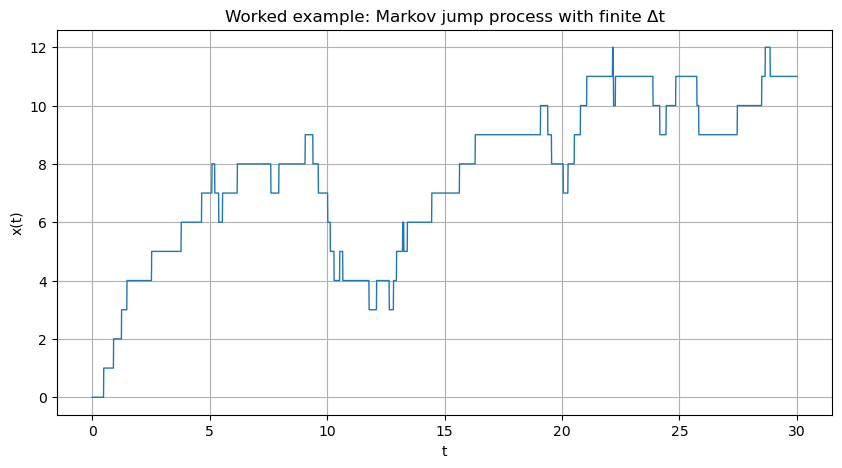

In [3]:
def simulate_markov_dt(T=100.0, dt=0.01, r=1.2, l=0.8, x0=0, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    n_steps = int(T / dt)
    times = np.linspace(0.0, T, n_steps + 1)
    x = np.empty(n_steps + 1, dtype=float)
    x[0] = x0

    p_r = r * dt
    p_l = l * dt
    if p_r + p_l > 1:
        raise ValueError("Choose a smaller dt so that (r+l)dt <= 1.")

    u = rng.random(n_steps)
    step = np.zeros(n_steps, dtype=int)
    step[u < p_r] = 1
    step[(u >= p_r) & (u < p_r + p_l)] = -1
    x[1:] = x0 + np.cumsum(step)
    return times, x

times, x = simulate_markov_dt(T=30, dt=0.01, r=1.2, l=0.8, rng=rng)
fig,ax = plt.subplots(figsize=(10,5))
ax.plot(times, x, lw=1)
ax.set_ylabel("x(t)")
ax.set_xlabel("t")
ax.set_title("Worked example: Markov jump process with finite Δt")

plt.show()

Check whether the motion is truly brownian: a graph of multiple iterations should result in a conical envelope of trajectories.

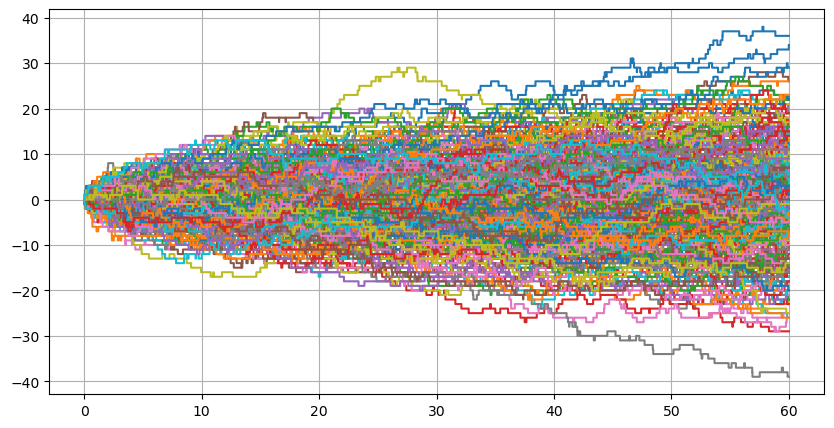

In [4]:
fig,ax = plt.subplots(figsize=(10,5))

for i in range(500):
    times, x = simulate_markov_dt(T=60, dt=0.01, r=1., l=1., rng=None)
    ax.step(times, x)

plt.show()

### Exercise 1.1
Modify the parameters:
- unbiased case: `r = l`,
- biased case: `r \neq l`,
- different values of `dt`.

What changes in the trajectory?
What happens if `dt` is chosen too large?

In [5]:
# TODO:
# Try several parameter choices and plot a few trajectories.

# Example:
# times, x = simulate_markov_dt(T=..., dt=..., r=..., l=..., rng=rng)
# plt.plot(times, x)
# plt.show()

### **Unbiased case**
Create more rng to plot a cloud of different trajectories.

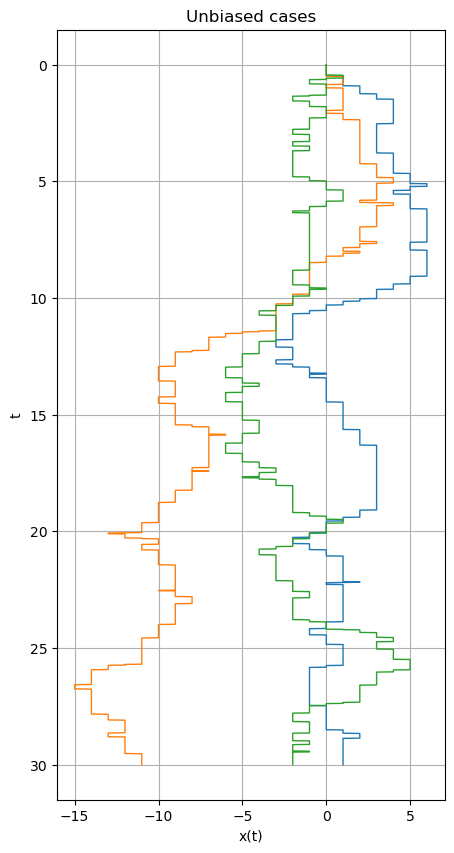

In [6]:
rng1 = np.random.default_rng(12345)
rng2 = np.random.default_rng(67890)
rng3 = np.random.default_rng(24689)

times, x1 = simulate_markov_dt(T=30, dt=0.01, r=1., l=1., rng=rng1)
_, x2 = simulate_markov_dt(T=30, dt=0.01, r=1., l=1., rng=rng2)
_, x3 = simulate_markov_dt(T=30, dt=0.01, r=1., l=1., rng=rng3)

fig,ax = plt.subplots(figsize=(5,10))

ax.plot(x1,times, lw=1)
ax.plot(x2,times, lw=1)
ax.plot(x3,times, lw=1)

ax.yaxis.set_inverted(True)
ax.set_xlabel("x(t)")
ax.set_ylabel("t")
ax.set_title("Unbiased cases")
plt.show()

### **Very biased case**

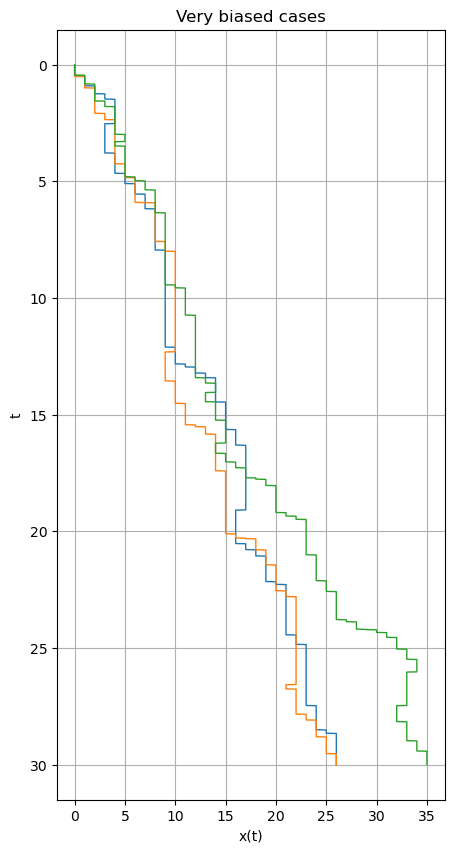

In [7]:
rng1 = np.random.default_rng(12345)
rng2 = np.random.default_rng(67890)
rng3 = np.random.default_rng(24689)

times, x1 = simulate_markov_dt(T=30, dt=0.01, r=1., l=0.1, rng=rng1)
_, x2 = simulate_markov_dt(T=30, dt=0.01, r=1., l=0.1, rng=rng2)
_, x3 = simulate_markov_dt(T=30, dt=0.01, r=1., l=0.1, rng=rng3)

fig,ax = plt.subplots(figsize=(5,10))

ax.plot(x1,times, lw=1)
ax.plot(x2,times, lw=1)
ax.plot(x3,times, lw=1)

ax.yaxis.set_inverted(True)
ax.set_xlabel("x(t)")
ax.set_ylabel("t")
ax.set_title("Very biased cases")
plt.show()

## 2. Gillespie simulation of the same process

For the exact continuous-time process:
- the total escape rate is $\lambda = r + \ell$,
- the residence time is exponentially distributed with density $\psi(\tau)=\lambda e^{-\lambda \tau}$,
- after a jump, the direction is chosen with probabilities
  $\pi_r = r/(r+\ell)$ and $\pi_\ell = \ell/(r+\ell)$.

This is the standard kinetic Monte Carlo / Gillespie construction.

### **Exercise 2.1**
Implement the Gillespie version.

Complete the function below:
1. draw a residence time from an exponential law with mean $1/(r+\ell)$,
2. choose the jump direction using $\pi_r$ and $\pi_\ell$,
3. build the piecewise-constant trajectory.

In [8]:
def simulate_markov_gillespie(T=100.0, r=1., l=1., x0=0, rng=None):

    if rng is None:
        rng = np.random.default_rng()

    lam = r+l
    pi_r = r/lam
    pi_l = l/lam

    t = 0
    times = np.array([])
    x = np.array([x0])

    # update times
    while t < T:
        tau = rng.exponential()
        if t + tau > T:
            break
        t += tau
        times = np.append(times, t)
    
    nsteps = len(times)-1

    # fill out steps
    steps = np.zeros(nsteps, dtype=int)
    mask = rng.random(size=nsteps)
    steps[mask < pi_r] = +1
    steps[(mask >= pi_r) & (mask < pi_r + pi_l)] = -1
    traj = np.cumsum(steps)
    x = np.append(x, traj)

    return times, x


#### **WTD consistency check**
Check whether the waiting time distribution is truly exponential. We plot an histogram of the waiting times along a very long trajectory.

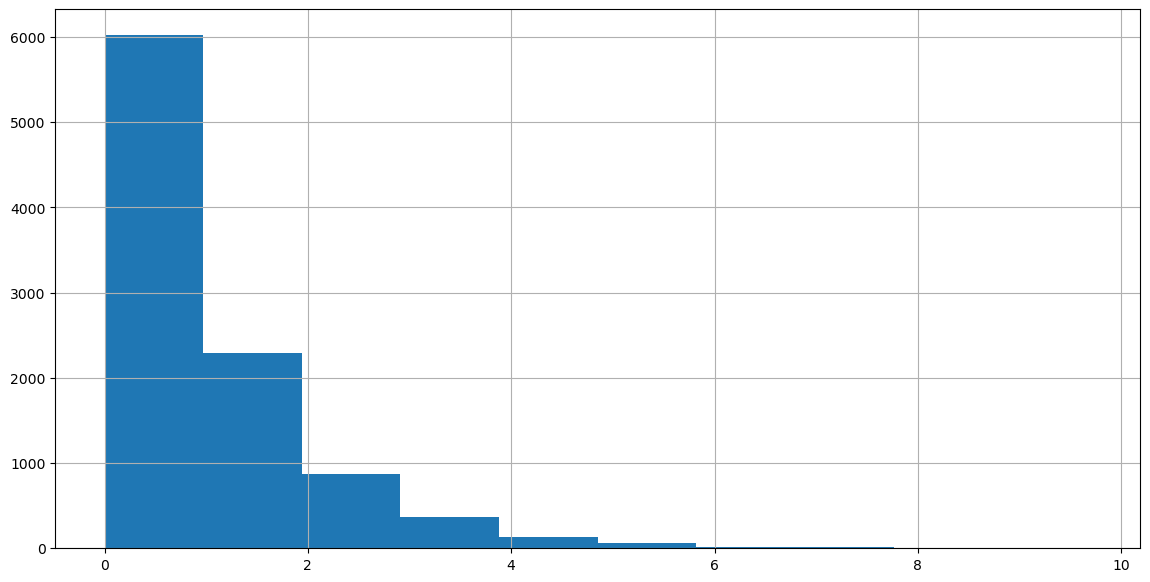

In [9]:
check_times, _ = simulate_markov_gillespie(T=10000.0, l=1., r=1., x0=0, rng=None)

plt.hist(np.diff(check_times))
plt.show()

#### **Unbiased case**

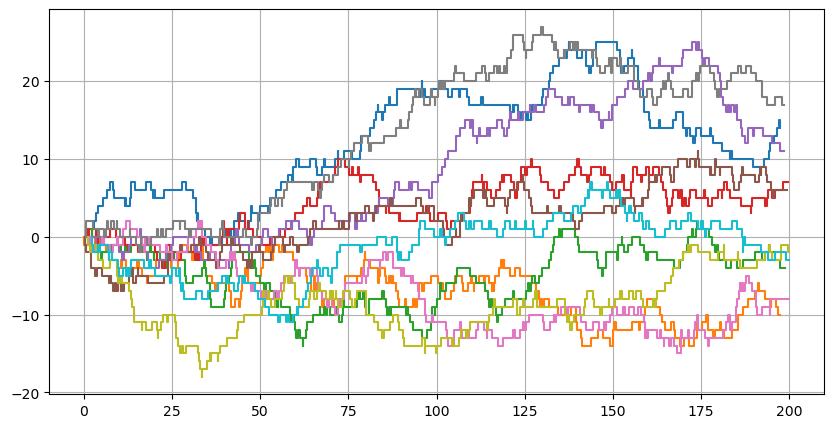

In [10]:
n_iterations = 10
fig,ax = plt.subplots(figsize=(10,5))

for n in range(n_iterations):
    times, x = simulate_markov_gillespie(T=200.0, l=1., r=1., x0=0, rng=None)
    ax.step(times, x)

plt.show()

#### **Biased case**

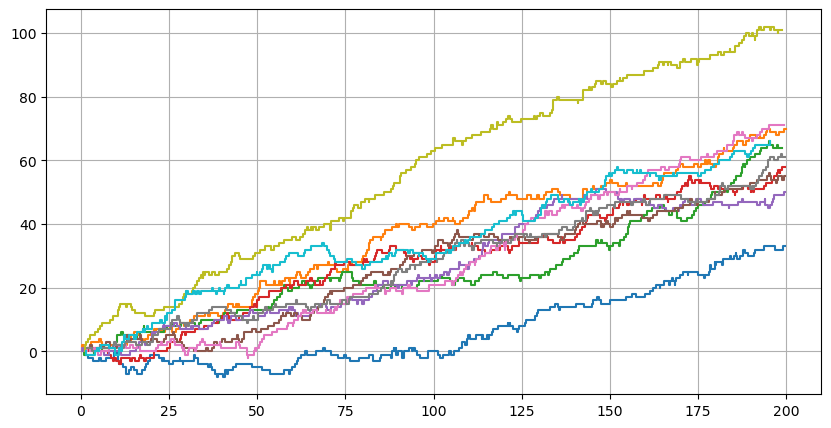

In [11]:
n_iterations = 10
fig,ax = plt.subplots(figsize=(10,5))

for n in range(n_iterations):
    times, x = simulate_markov_gillespie(T=200.0, l=0.7, r=1.3, x0=0, rng=None)
    ax.step(times, x)

plt.show()

## 3. Extracting scaled cumulants and checking diffusive growth

For many trajectories, estimate:
- the average current $\langle x(t)\rangle/t$,
- the scaled variance $\mathrm{Var}[x(t)]/t$,
- the ensemble MSD.

The goal is to verify that the Markov case is normally diffusive.

In [12]:
def sample_piecewise_on_grid(event_times, event_pos, t_grid):
    idx = np.searchsorted(event_times, t_grid, side="right") - 1
    idx = np.clip(idx, 0, len(event_pos) - 1)
    return event_pos[idx]

def generate_markov_ensemble(n_traj=500, T=100.0, n_grid=400, r=1., l=1., rng=None):
    if rng is None:
        rng = np.random.default_rng()
        
    t_grid = np.linspace(0, T, n_grid)
    X = np.empty((n_grid, n_traj))
    
    for k in range(n_traj):
        times, x_raw = simulate_markov_gillespie(T=T, r=r, l=l, x0=0, rng=rng)
        x_ind = np.arange(0, len(x_raw))
        x_ind_grid = sample_piecewise_on_grid(times, x_ind, t_grid)
        x = x_raw[x_ind_grid]
        X[:, k] = x
        
    return t_grid, X

/tmp/ipykernel_48681/2358417423.py:9: RuntimeWarning: invalid value encountered in divide
  mean_X = np.mean(X, axis=1) / times


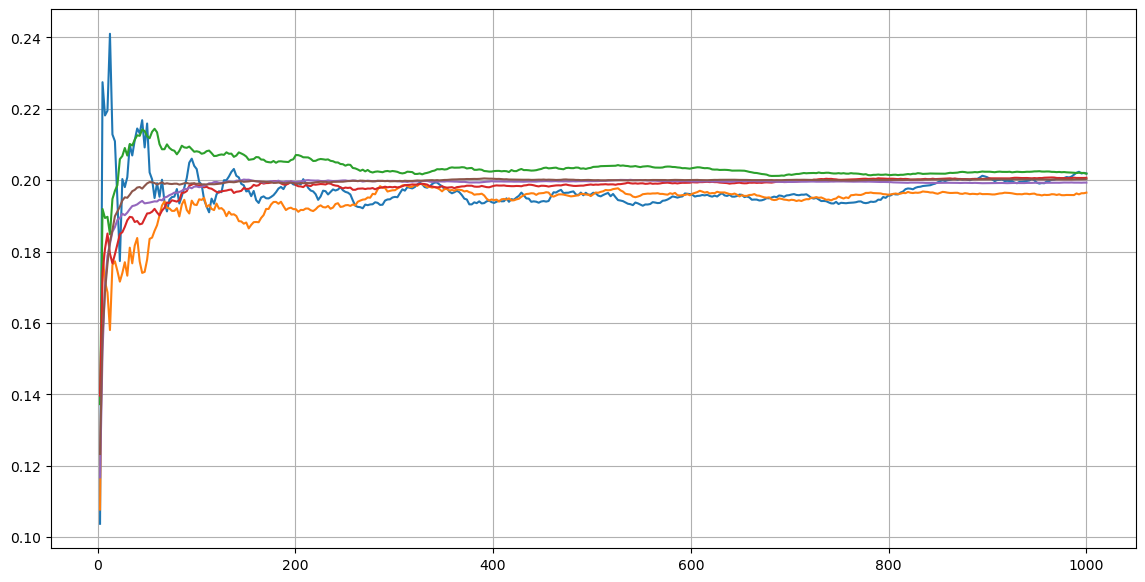

In [13]:
n_traj = [50, 100, 500, 1000, 5000, 10000]
T = 1000.0
n_grid = 400
r = 1.2
l = 0.8

for k in range(len(n_traj)):
    times, X = generate_markov_ensemble(n_traj=n_traj[k], T=T, n_grid=n_grid, r=r, l=l, rng=None)
    mean_X = np.mean(X, axis=1) / times
    plt.plot(times, mean_X)

plt.show()

/tmp/ipykernel_48681/1589922057.py:9: RuntimeWarning: invalid value encountered in divide
  var_X = np.var(X, axis=1) / times


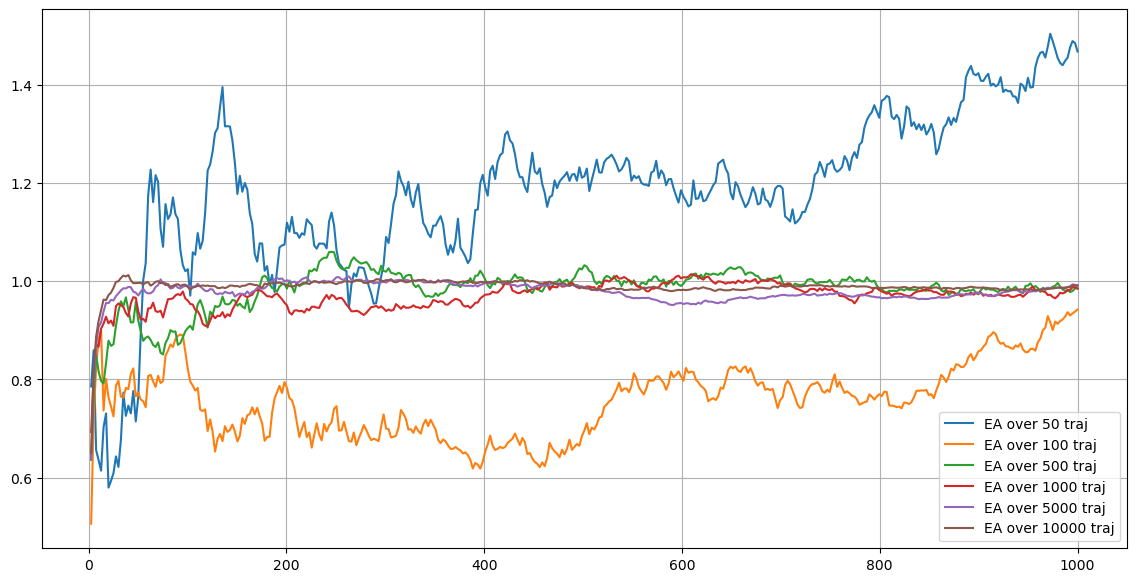

In [14]:
n_traj = [50, 100, 500, 1000, 5000, 10000]
T = 1000.0
n_grid = 400
r = 1.2
l = 0.8

for k in range(len(n_traj)):
    times, X = generate_markov_ensemble(n_traj=n_traj[k], T=T, n_grid=n_grid, r=r, l=l, rng=None)
    var_X = np.var(X, axis=1) / times
    plt.plot(times, var_X, label=f'EA over {n_traj[k]} traj')

plt.legend()
plt.show()

## 4. CTRW with a power-law waiting time distribution

We now replace the exponential waiting time by a heavy-tailed law
$$
\psi(\tau) \sim \tau^{-1-\alpha}, \qquad 0<\alpha<1.
$$

A convenient exact sampler is obtained from a Pareto-type density
$$
\psi(\tau)=\frac{\alpha\tau_0^\alpha}{(\tau+\tau_0)^{1+\alpha}},
$$
which can be sampled through inverse transform.

This distribution has infinite mean waiting time for $0<\alpha<1$.
That is the source of subdiffusion and weak ergodicity breaking.

**Notes**

The cumulant for the inverse transform is:

$$
1 - \left( \frac{t_0}{t-t_0} \right)^\alpha
$$

so that the inverse is:

$$
t = t_0 \left(\left(1-c(t)\right)^{-1/\alpha} - 1 \right)
$$

### Exercise 4.1
Implement a CTRW with a power-law waiting time distribution.

Use the inverse-transform formula for the waiting times.
Then simulate:
- free diffusion: `p_right = 0.5`,
- biased diffusion: `p_right > 0.5`.

In [24]:
def sample_power_law_waiting(alpha=0.7, tau0=1.0, size=None, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    if size is None:
        rand = rng.uniform()
        y = tau0*((1-rand)**(-1/alpha) - 1)
    else:
        rand = rng.uniform(size=size)
        y = tau0*((1-rand)**(-1/alpha) - 1)

    return y

def simulate_powerlaw_ctrw(T=1000.0, alpha=0.7, tau0=1.0, r=0.5, l=0.5, x0=0, rng=None):


    if rng is None:
        rng = np.random.default_rng()

    lam = r+l
    pi_r = r/lam
    pi_l = l/lam

    t = 0
    times = np.array([0])
    x = np.array([x0])

    # update times
    while t < T:
        tau = sample_power_law_waiting(alpha=alpha, tau0=tau0)
        if t + tau > T:
            times = np.append(times, T)
            break
        t += tau
        times = np.append(times, t)
    
    nsteps = len(times)-1
    
    # fill out steps
    steps = np.zeros(nsteps, dtype=int)
    mask = rng.random(size=nsteps)
    steps[mask < pi_r] = +1
    steps[(mask >= pi_r) & (mask < pi_r + pi_l)] = -1
    traj = np.cumsum(steps)
    x = np.append(x, traj)
    x[-1] = x[-2]

    return times, x

#### Test with unbiased trajectories

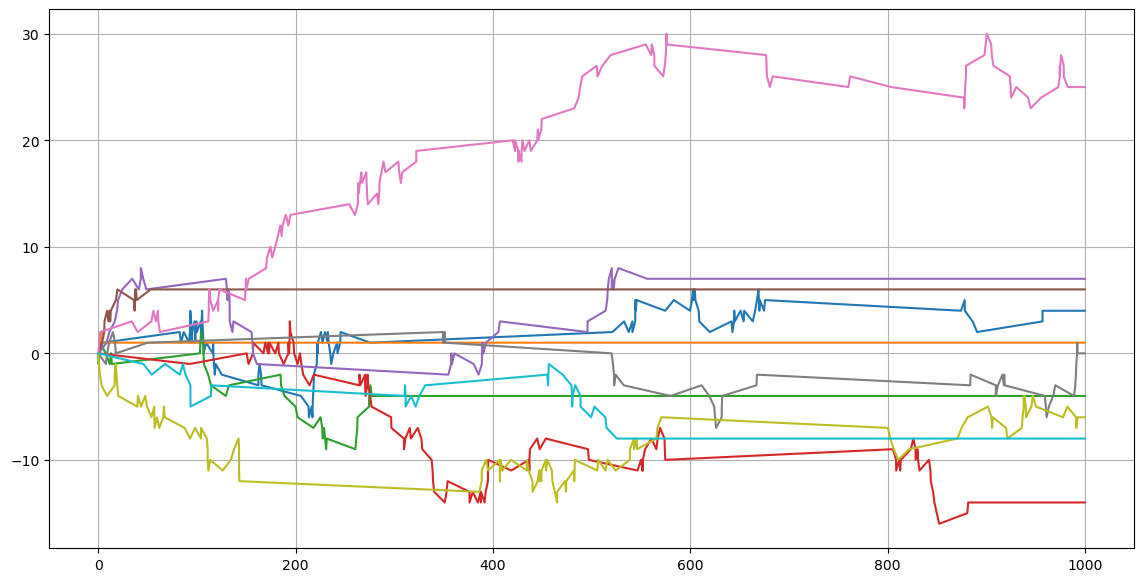

In [26]:
n_traj = 10

for k in range(n_traj):
    times, x = simulate_powerlaw_ctrw(T=1000.0, alpha=0.7, tau0=1.0, r=0.5, l=0.5, x0=0, rng=None)
    plt.plot(times,x)

#### Test with biased trajectories

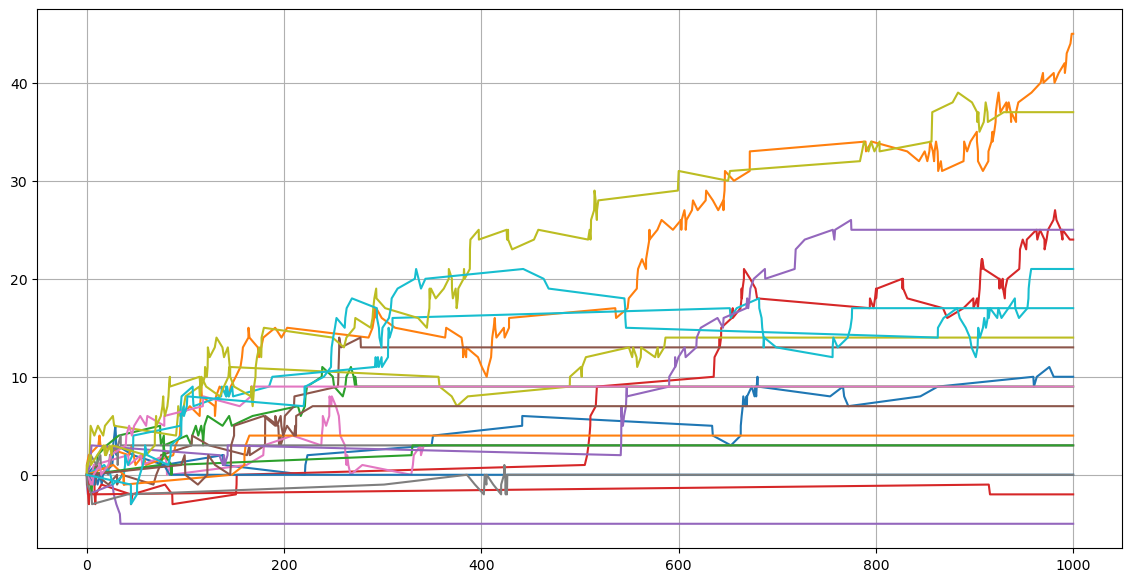

In [27]:
n_traj = 20

for k in range(n_traj):
    times, x = simulate_powerlaw_ctrw(T=1000.0, alpha=0.7, tau0=1.0, r=1.2, l=0.8, x0=0, rng=None)
    plt.plot(times,x)

## 5. EAMSD, TEAMSD, anomalous exponents, and weak ergodicity breaking

For each trajectory sampled on a common observation grid, we can compute:

- EAMSD:
$$
\langle [x(t)-x(0)]^2 \rangle
$$

- time-averaged MSD (for lag $\Delta$):
$$
\overline{\delta^2(\Delta)}
=
\frac{1}{T-\Delta}
\int_0^{T-\Delta}
[x(t+\Delta)-x(t)]^2\,dt \sim \Delta \cdot T^{\,\alpha-1}
$$

For subdiffusive CTRWs:
- unbiased case: EAMSD $\sim t^\alpha$,
- biased case: EAMSD of the displacement typically shows stronger growth, asymptotically $\sim t^{2\alpha}$ when the drift dominates, while fluctuations around the mean remain sublinear,
- TEAMSD behaves differently from EAMSD, revealing weak ergodicity breaking.

### Exercise 5.1
Generate enough trajectories and estimate:
- the EAMSD for the free case,
- the EAMSD for the biased case,
- a collection of TAMSD curves.

You should then discuss:
1. the qualitative appearance of the trajectories,
2. the relation between $\alpha$ and the MSD exponent,
3. the evidence of weak ergodicity breaking.

In [32]:
def generate_powerlaw_ensemble(n_traj=300, T=5000.0, n_grid=500, alpha=0.7, tau0=1.0, r=1., l=1., rng=None):
    if rng is None:
        rng = np.random.default_rng()
        
    t_grid = np.linspace(0, T, n_grid)
    X = np.empty((n_grid, n_traj))
    
    for k in range(n_traj):
        times, x_raw = simulate_powerlaw_ctrw(T=T, alpha=alpha, tau0=tau0, r=r, l=l, x0=0, rng=rng)
        x_ind = np.arange(0, len(x_raw))
        x_ind_grid = sample_piecewise_on_grid(times, x_ind, t_grid)
        x = x_raw[x_ind_grid]
        X[:, k] = x
        
    return t_grid, X

def time_averaged_msd(times, x, lag):
    dt = times[1] - times[0]
    lag_step = max(1, int(round(lag / dt)))
    return np.mean((x[lag_step:] - x[:-lag_step]) ** 2)

Text(0, 0.5, 'TAMSD')

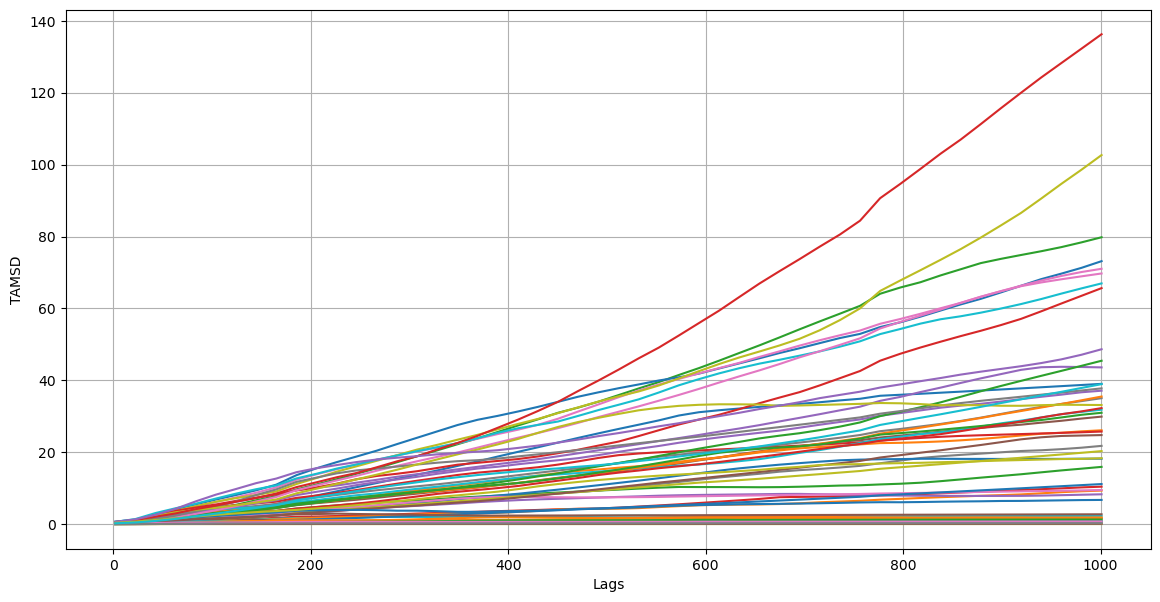

In [33]:
n_traj = 50

t_grid, x = generate_powerlaw_ensemble(n_traj=n_traj, T=5000.0, n_grid=500, alpha=0.7, tau0=1.0, r=1., l=1., rng=None)
lags = np.linspace(2,1001)
ta_msd = np.empty((len(lags), n_traj))

for k in range(n_traj):
    ta_msd[:,k] = [time_averaged_msd(t_grid, x[:,k], lag) for lag in lags]
    plt.plot(lags, ta_msd[:,k])

plt.xlabel('Lags')
plt.ylabel(('TAMSD'))

### Questions for discussion
- **How does the trajectory look when compared with a Brownian-like trajectory?** The anomalous trajectory is more resilient to the bias influence and allows for longer and more frequent plateaus.

- **How do the plateaus depend on $\alpha$?** The smaller $\alpha$ is, the "fatter" the tail. Therefore, the easier it is for the trajectory to sample a longer-than-usual waiting time. Thus, more and longer plateaus emerge as $\alpha$ gets smaller.

- **In the unbiased case, what exponent do you measure for the EAMSD?** (1?)
- **In the biased case, what exponent do you measure for the displacement EAMSD?** (alpha?)
- **Why does the mismatch between EAMSD and TAMSD indicate weak ergodicity breaking?** Because the anomalous trajectory can leave the phase subspace only in the $t\to\infty$ limit; therefore, the ensemble average takes into account a much wider section of the phase space.

## 6. Decimation

We now coarse-grain the Markovian random walk by observing only every second site.
A convenient way to generate the decimated trajectory is:
- simulate the full nearest-neighbour Markov process,
- record only the successive visits to the even sublattice,
- measure the effective waiting times between those coarse-grained jumps.

For a biased nearest-neighbour Markov process, the decimated dynamics is generally non-Markovian.
The effective waiting-time distribution is no longer exponential.

### Exercise 6.1
Create the decimated trajectory by keeping only every second site.
Then measure the effective waiting-time distribution between successive jumps on the coarse lattice.

Compare the histogram with the analytical form derived in class.

In [ ]:
# provv

def simulate_markov_gillespie(T=100.0, r=1., l=1., x0=0, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    lam = r + l
    pi_r = r / lam
    t = 0.0
    times = [0.0]
    x_vals = [x0]
    while t < T:
        tau = rng.exponential(1 / lam)
        if t + tau > T:
            break
        t += tau
        times.append(t)
        step = 1 if rng.random() < pi_r else -1
        x_vals.append(x_vals[-1] + step)
    return np.array(times), np.array(x_vals)


def decimate_even_sites(times, x):
    x = x.squeeze()
    dec_ind = np.where(x % 2 == 0)[0]
    dec_times = times[dec_ind]
    dec_x = x[dec_ind]
    keep = np.concatenate(([True], np.diff(dec_x) != 0))
    return dec_times[keep], dec_x[keep], dec_ind[keep]



def collect_decimated_waiting_times_markovian(n_traj=2000, T=500.0, r=1., l=1., rng=None):
    if rng is None:
        rng = np.random.default_rng()
    times_histogram_raw = []
    jumps_histogram_raw = []
    for k in range(n_traj):
        times, x = simulate_markov_gillespie(T=T, r=r, l=l, x0=0, rng=rng)
        dec_times, dec_x, _ = decimate_even_sites(times, x)
        if len(dec_times) > 1:
            times_histogram_raw.append(np.diff(dec_times))
            jumps_histogram_raw.append(np.diff(dec_x))
    times_histogram = np.concatenate(times_histogram_raw)
    jumps_histogram = np.concatenate(jumps_histogram_raw)
    return times_histogram, jumps_histogram


def decimate_odd_sites(times, x):
    x = x.squeeze()
    even_mask = (x % 2 == 0)
    dec_ind = np.where(even_mask)[0]
    dec_times = times[dec_ind]
    dec_x     = x[dec_ind]
    keep = np.concatenate(([True], np.diff(dec_x) != 0))
    return dec_times[keep], dec_x[keep], dec_ind[keep]
    

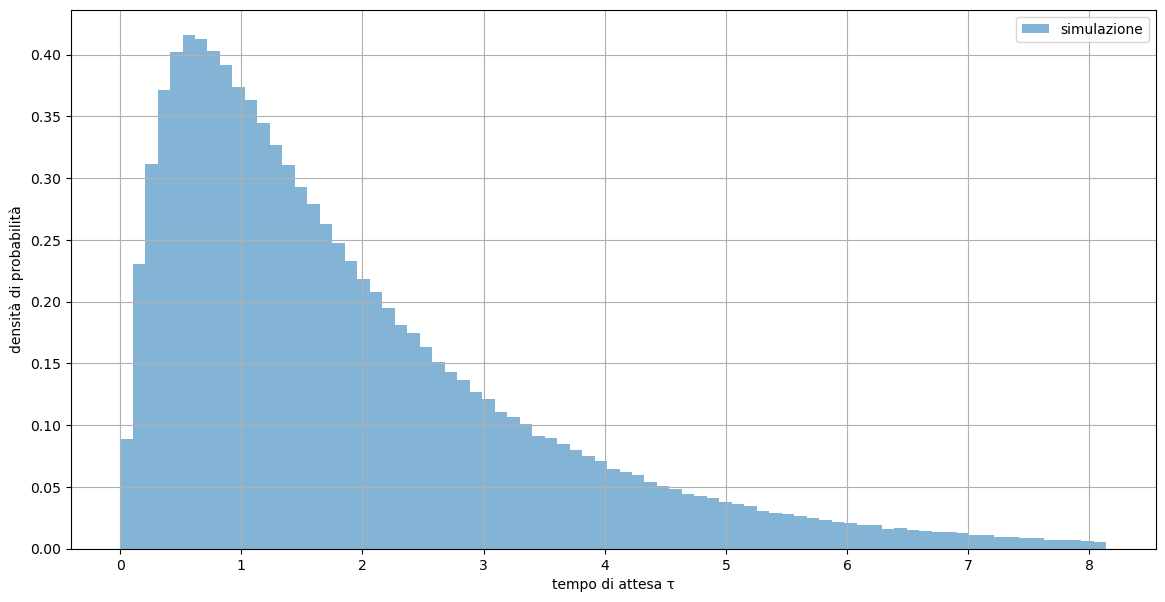

In [ ]:
wt, jt = collect_decimated_waiting_times_markovian(n_traj=2000, T=500.0, r=1., l=1.)

t_max = np.percentile(wt, 99)
bins = np.linspace(0, t_max, 80)

plt.hist(wt, bins=bins, density=True)
plt.xlabel('Waiting time')
plt.ylabel('Probability density')
plt.show()

In [ ]:
def decimate_odd_sites(times, x):  # even = pari
    x = x.squeeze()
    dec_ind = np.nonzero((x%2) == 0)
    
    dec_x = x[dec_ind]
    dec_times = times[dec_ind]

    return dec_times, dec_x, dec_ind

    

def collect_decimated_waiting_times_markovian(n_traj=1000, T=200.0, n_grid=10000, r=1., l=1., rng=None):
    if rng is None:
        rng = np.random.default_rng()

    times, X = generate_markov_ensemble(n_traj=n_traj, T=T, n_grid=n_grid, r=r, l=l, rng=rng)
    
    times_histogram_raw = []
    jumps_histogram_raw = []
    for k in range(n_traj):
        dec_times, dec_x, _ = decimate_even_sites(times, X[:,k])
        times_histogram_raw.append(np.diff(dec_times))
        jumps_histogram_raw.append(np.diff(dec_x))

    times_histogram = np.concatenate(times_histogram_raw)
    jumps_histogram = np.concatenate(jumps_histogram_raw)
    
    return times_histogram, jumps_histogram

[  0.           3.050061     6.9701394    7.9101582    9.9401988
  12.59025181  13.05026101  14.08028161  16.35032701  19.17038341
  22.23044461  24.24048481  25.04050081  25.63051261  26.05052101
  26.81053621  30.94061881  35.18070361  35.99071981  36.27072541
  36.67073341  37.38074761  42.46084922  42.90085802  46.18092362
  53.71107422  54.49108982  56.90113802  57.73115462  58.22116442
  60.05120102  61.38122762  62.44124882  63.00126003  63.23126463
  63.46126923  64.54129083  66.12132243  69.28138563  70.88141763
  72.08144163  72.88145763  73.09146183  73.91147823  75.53151063
  75.67151343  81.58163163  82.01164023  83.91167823  84.16168323
  85.48170963  86.38172763  87.65175304  88.22176444  89.68179364
  91.83183664  94.53189064  95.37190744  95.92191844  99.03198064
 102.20204404 103.65207304 105.48210964 106.82213644 109.05218104
 110.52221044 113.50227005 114.97229945 116.54233085 117.11234225
 122.54245085 123.47246945 124.98249965 127.34254685 129.63259265
 130.952619

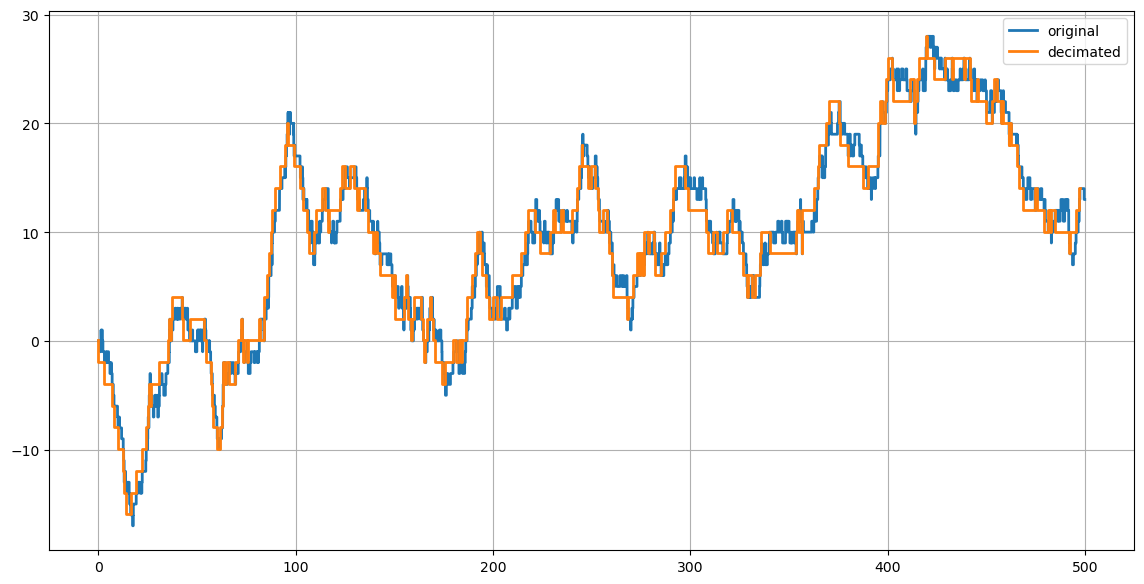

In [ ]:






times, X = generate_markov_ensemble(n_traj=1, T=500., n_grid=50000, r=1., l=1., rng=None)
times_dec, X_dec, _ = decimate_odd_sites(times,X)

print(times_dec)
print(X_dec)


plt.step(times,X, lw=2, label='original')
plt.step(times_dec, X_dec+0.05, lw=2, label='decimated')
plt.legend()
plt.show()

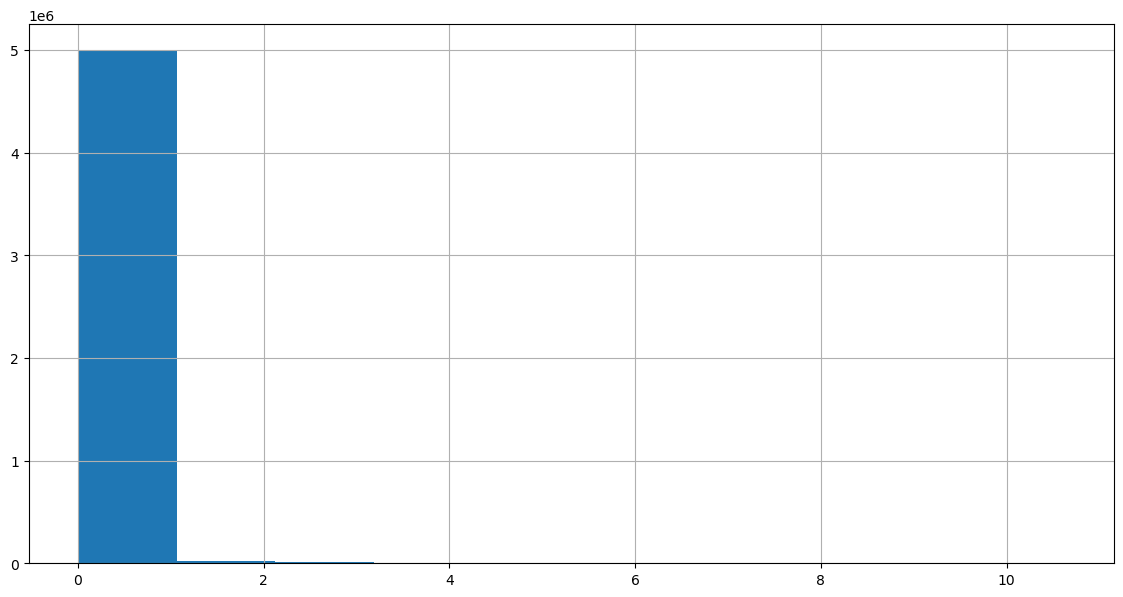

In [222]:
times_histogram, jumps_histogram = collect_decimated_waiting_times_markovian()

counts, bin_edges = np.histogram(times_histogram)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

plt.bar(bin_centers, counts, width=np.diff(bin_edges), align='center')
plt.show()

## 7. Lumping

Now group adjacent sites into pairs.
For instance:
$$
\{0,1\}\to 0, \quad \{2,3\}\to 1, \quad \{-2,-1\}\to -1, \dots
$$

Again record the effective waiting times between successive coarse jumps.
This exercise should highlight the contrast between:
- decimation: deleting states,
- lumping: merging states.

The resulting coarse waiting-time distributions need not coincide.

### Exercise 7.1
Repeat the same analysis for lumping, by grouping adjacent sites in pairs.

Then compare the coarse waiting-time histogram with the decimation case.
What is the conceptual difference between deleting states and merging states?

In [ ]:
def pair_lump(x):
    # TODO:
    # Map integers into blocks of size 2.
    # Example: 0,1 -> 0 ; 2,3 -> 1 ; -2,-1 -> -1
    raise NotImplementedError("Implement the lumping map.")

def lump_adjacent_pairs(event_times, event_pos):
    # TODO:
    # Build the coarse trajectory and remove consecutive duplicates.
    raise NotImplementedError("Implement the lumped trajectory.")

def collect_lumped_waiting_times(n_traj=1000, T=200.0, r=1.2, l=0.8, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    # TODO:
    # simulate, lump, and collect waiting times
    raise NotImplementedError("Collect the lumped statistics.")

In [ ]:
# TODO:
# Compare the lumped waiting-time histogram with the decimated one.

## 8. Homework: iterative RG under decimation

Try to implement the iterative renormalization-group scheme for decimation.
The target is to show numerically that, for waiting-time distributions with finite mean, repeated decimation flows toward the same fixed-point RTD discussed in class.

Suggested steps:
1. Start from several microscopic waiting-time laws with finite mean.
2. Compute the induced decimated RTD numerically.
3. Use the output as the input for the next decimation step.
4. Compare the rescaled RTDs after each iteration.
5. Test convergence toward the universal fixed point.

Possible extensions:
- compare finite-mean and infinite-mean cases,
- monitor moments when they exist,
- work in Laplace space if that is more convenient.

## Submission suggestions

For each exercise, include:
- the code you completed,
- one or two representative figures,
- a short interpretation of the results.

For the anomalous CTRW section, make sure you comment on both EAMSD and TAMSD.